#### Loading training and validation datasets

Import libraries and set directories

In [7]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter # To count the number of occurrences of each label

DATA_DIR = Path.home() / "Desktop" / "gnn_trajectory" / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

train_path = PROCESSED_DATA_DIR / "nuscenes_train_prediction_samples.pkl"
val_path = PROCESSED_DATA_DIR / "nuscenes_val_prediction_samples.pkl"

# Load dataset
with open(train_path, "rb") as f: # rb = read binary
    train_dataset = pickle.load(f)
    
with open(val_path, "rb") as f: 
    val_dataset = pickle.load(f)
    
print("Train samples: ",len(train_dataset))
print("Val samples: ",len(val_dataset))

Train samples:  25711
Val samples:  7242


#### Constant velocity baseline

For each sample we estimate the velocity from the past target. Since data is at 0.5 s intervals (2 Hz) we compute velocity as $v$ and predict 
$p_t$ as: 

$$v = \frac{p_t - p_{t-1}}{0.5} \ \ \ \ \  \hat p_t = p_{0} + v \cdot t$$

for the next **12** steps starting from $p_0$ (current position).

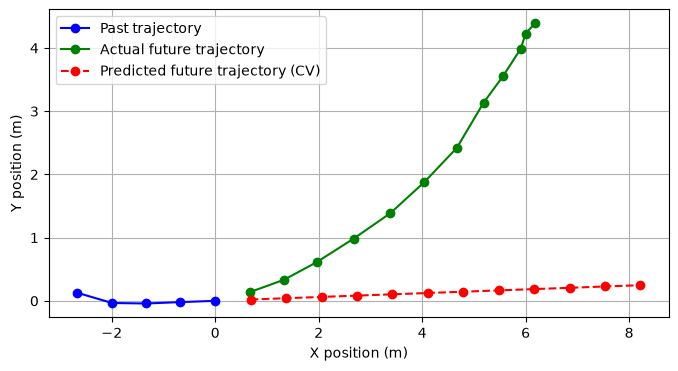

In [2]:
import numpy as np

def constant_velocity_prediction(target_past, future_steps=12, dt=0.5): 
    
    p_prev = target_past[-2] # get last 2s  
    p_current = target_past[-1] # 
    
    velocity = (p_current - p_prev) / dt  
    
    predictions = []
    
    for step in range(1, future_steps + 1):
        t = step * dt
        pred = p_current + velocity * t
        predictions.append(pred)
        
    return np.array(predictions)

sample = val_dataset[0]
y_past = sample['target_past']

# Compare y_hat and y
y_hat = constant_velocity_prediction(sample['target_past'])
y = sample['target_future']

plt.figure(figsize=(8, 4))
plt.plot(y_past[:, 0], y_past[:, 1], 'bo-', label='Past trajectory')
plt.plot(y[:, 0], y[:, 1], 'go-', label='Actual future trajectory')
plt.plot(y_hat[:, 0], y_hat[:, 1], 'ro--', label='Predicted future trajectory (CV)')
plt.xlabel('X position (m)'); plt.ylabel('Y position (m)')
plt.legend(); plt.grid()  

#### Benchmarking
For benchmarking, we compute the average displacement error (ADE) and final displacement error (FDE) for each sample in the validation set. 

```bash
- ADE will tell, on average, how far the predicted trajectory is from the ground truth trajectory.
```
```bash
- FDE tells how wrong the final 6s position is
```

\begin{equation}
ADE = \frac{1}{12} \sum_{t=1}^{12} \sqrt{(x_t - \hat{x}_t)^2 + (y_t - \hat{y}_t)^2}
\end{equation}


In [3]:
def compute_ade_fde(pred_future, target_future):
    pred_future = np.asarray(pred_future)
    target_future = np.asarray(target_future)
    errors = np.linalg.norm(pred_future - target_future, axis=1)
    return errors.mean(), errors[-1]

# Sample error
ade, fde = compute_ade_fde(y_hat, sample["target_future"])
# print("ADE:", ade)
# print("FDE:", fde)

# For all validation samples
cv_ade_list = []
cv_fde_list = []

for sample in val_dataset: 
    y_hat = constant_velocity_prediction(sample['target_past'])
    ade, fde = compute_ade_fde(y_hat, sample["target_future"])
    
    cv_ade_list.append(ade)
    cv_fde_list.append(fde)
    
# mean ADE and FDE
cv_ade_mean = np.mean(cv_ade_list)
cv_fde_mean = np.mean(cv_fde_list)

print("Validation samples:", len(val_dataset))
print("Constant Velocity Baseline - Mean ADE:", cv_ade_mean)
print("Constant Velocity Baseline - Mean FDE:", cv_fde_mean)    

Validation samples: 7242
Constant Velocity Baseline - Mean ADE: 4.6721587
Constant Velocity Baseline - Mean FDE: 11.287091


- On average, across all 12 future points, CV is about 4.67 m away from the true trajectory.
- At the final 6-second point, it is about 11.29 m away

#### Prepare data for GNN 

Check Notion page  [here](https://good-bluebell-9e8.notion.site/NuScenes-data-3e61be03c31580a5b85ce80655d3947c?source=copy_link) for more information about the data strucuture and how to prepare it for GNN training.

Target past shape: (5, 2)
Target future shape: (12, 2)
Number of neighbors: 8
Number of Nodes: 9
Neighbor 0: (5, 2) vehicle.truck
Neighbor 1: (5, 2) vehicle.car
Neighbor 2: (5, 2) vehicle.truck
Neighbor 3: (5, 2) vehicle.car
Neighbor 4: (5, 2) vehicle.truck
Neighbor 5: (5, 2) vehicle.car
Neighbor 6: (5, 2) vehicle.truck
Neighbor 7: (5, 2) vehicle.car

Metadata split: v1.0-trainval
Scene token: bebf5f5b2a674631ab5c88fd1aa9e87a
Camera images for this sample:
CAM_BACK: /home/danilo/Desktop/gnn_trajectory/data/sweeps/CAM_BACK/n008-2018-08-27-11-48-51-0400__CAM_BACK__1535385094387558.jpg (valid image)
CAM_BACK_LEFT: /home/danilo/Desktop/gnn_trajectory/data/sweeps/CAM_BACK_LEFT/n008-2018-08-27-11-48-51-0400__CAM_BACK_LEFT__1535385094297405.jpg (valid image)
CAM_BACK_RIGHT: /home/danilo/Desktop/gnn_trajectory/data/samples/CAM_BACK_RIGHT/n008-2018-08-27-11-48-51-0400__CAM_BACK_RIGHT__1535385094528113.jpg (valid image)
CAM_FRONT: /home/danilo/Desktop/gnn_trajectory/data/sweeps/CAM_FRONT/n008-20

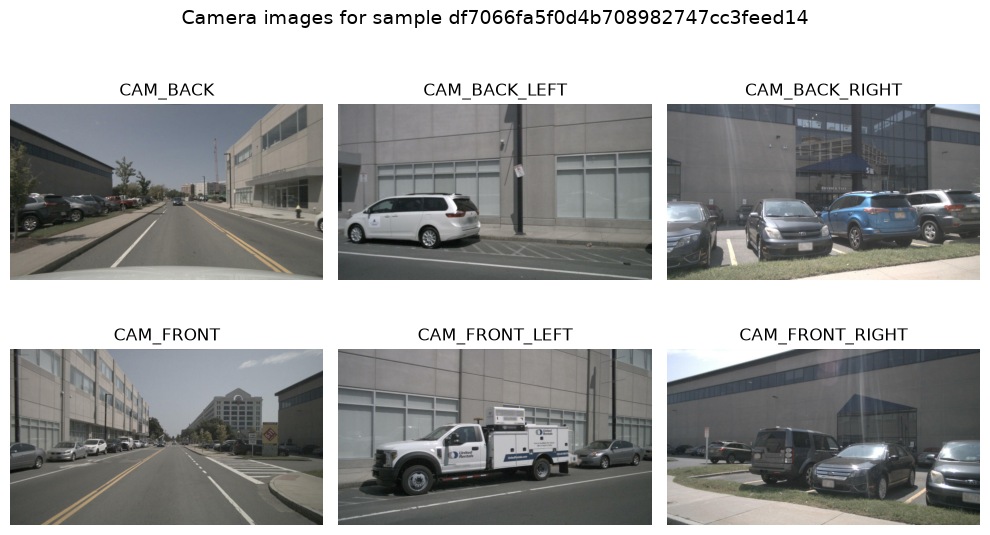

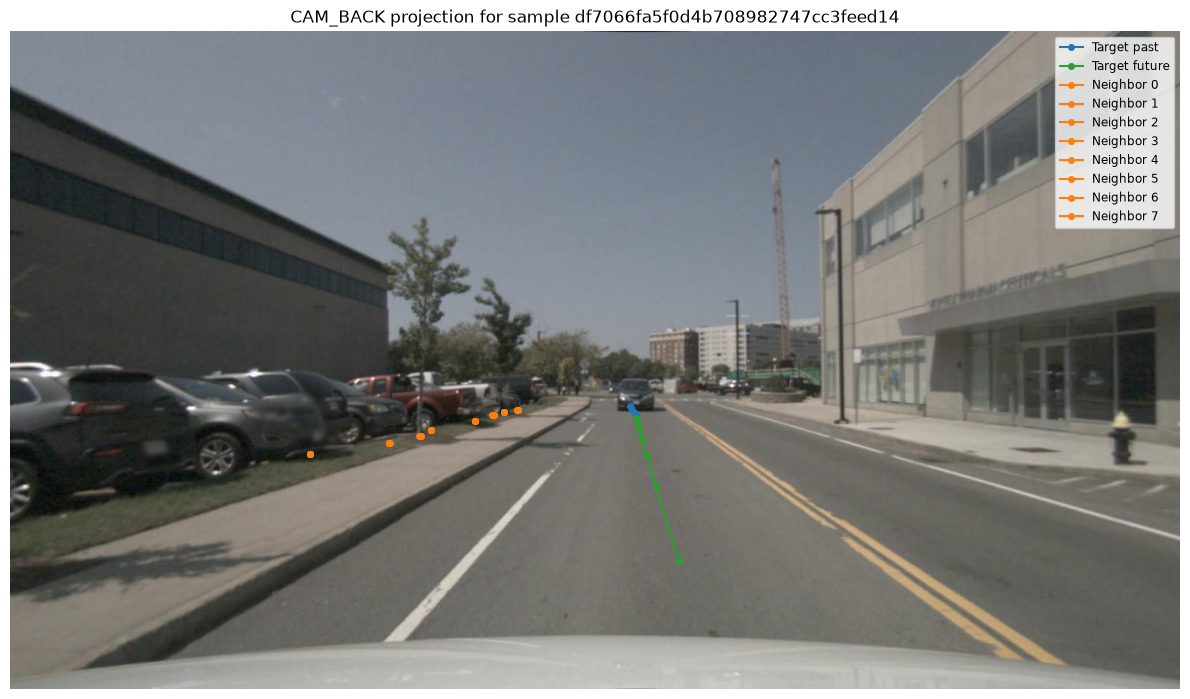

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'CAM_BACK projection for sample df7066fa5f0d4b708982747cc3feed14'}>)

In [5]:
sample = train_dataset[8842]

print("Target past shape:", sample["target_past"].shape)
print("Target future shape:", sample["target_future"].shape)
print("Number of neighbors:", len(sample["neighbors_pasts"]))
print("Number of Nodes:", len(sample["neighbors_pasts"]) + 1) # +1 for target node

for i, (past, category) in enumerate(zip(
    sample["neighbors_pasts"],sample["neighbors_categories"])):
    print(f"Neighbor {i}:",past.shape,category)
   

# Visualize all camera images and project onto the camera facing the target
import sys

sys.path.insert(0, str(DATA_DIR.parent / "scripts"))
from view_sample_image import view_sample_images
from project_sample_to_camera import plot_sample_camera_projection

view_sample_images(sample, DATA_DIR)
plot_sample_camera_projection(sample, DATA_DIR, channel="CAM_BACK")

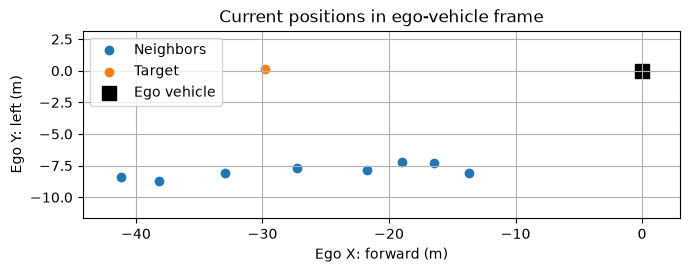

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'Current positions in ego-vehicle frame'}, xlabel='Ego X: forward (m)', ylabel='Ego Y: left (m)'>)

In [12]:
import sys
import importlib

sys.path.insert(0, str(DATA_DIR.parent / "scripts"))
import project_sample_to_camera
importlib.reload(project_sample_to_camera)

project_sample_to_camera.plot_sample_ego_frame(sample, DATA_DIR)

**Coordinate-frame note**: The nuScenes camera images are captured from the ego vehicle, i.e. the sensor-equipped data-collection car. The trajectory-prediction target is a separate annotated road user. Our trajectory plots are transformed into the target vehicle's local frame, where the target is located at \((0,0)\). Therefore, the origin of the trajectory plot does not correspond to the camera/ego vehicle. The same target may, for example, lie behind the ego vehicle and consequently appear in `CAM_BACK`

In [85]:
# TODO: Organize helper functions into a separate script for better modularity
import helper_functions
importlib.reload(helper_functions)
from helper_functions import general_category

# Category mapping
category_to_idx = {
    "car": 0,
    "large_vehicle": 1,
    "two_wheeler": 2,
    "pedestrian": 3,
    "other_vehicle": 4
}

# One-hot encoding function 
def category_one_hot(category):
    general = general_category(category)

    one_hot = np.zeros(5, dtype=np.float32)
    one_hot[category_to_idx[general]] = 1.0

    return one_hot

#### Verify node format for one sample
$x_i = [\text{trajectory}, \text {category}]$ where trajectory is a has N x (2 (x,y) coordinates) + 5 one hot encoded category vector. and N is the nº of Nodes in this sample

In [87]:
node_features = []


# TARGET = NODE 0
target_traj = sample["target_past"].flatten() # 10 elements  = (x_{t-4}, y_{t-4}, ..., x_{t}, y_{t}) 
target_one_hot = category_one_hot(sample["target_category"]) # -> one hot vector of length 5
target_features_vector = np.concatenate((target_traj, target_one_hot)) # 15 elements


node_features.append(target_features_vector) # with target node as the first element


# NEIGHBORS = NODES 1-4
for neighbor_past, category in zip(sample["neighbors_pasts"], sample["neighbors_categories"]): 
    
    neighbor_traj = neighbor_past.flatten() # 10 elements (x/y_{-4} to x/y_{5})
    neighbor_one_hot = category_one_hot(category) # -> one hot vector of length 5
    
    features = np.concatenate((neighbor_traj, neighbor_one_hot)) # 15 elements
    
    # Append to node_features list
    node_features.append(features)
    
# Stack all node features 
x = np.array(node_features, dtype=np.float32) # shape: (num_nodes, feature_dim = 15)

print("Node features array shape:", x.shape)
print(x) 

# 9 Nodes x 15 features = 135 elements in total for this sample

Node features array shape: (9, 15)
[[-14.022786    -0.25087366 -10.288019    -0.17162111  -6.85731
   -0.11481261  -3.047169    -0.05151617   0.           0.
    1.           0.           0.           0.           0.        ]
 [ -3.239977    -8.331206    -3.2375863   -8.294283    -3.2352705
   -8.259312    -3.2328424   -8.221414    -3.230596    -8.191448
    0.           1.           0.           0.           0.        ]
 [ 16.078722    -8.446189    16.078722    -8.446189    16.078722
   -8.446189    16.078722    -8.446189    16.078722    -8.446189
    1.           0.           0.           0.           0.        ]
 [ 13.225913    -7.6295037   13.249457    -7.614402    13.270037
   -7.600164    13.292604    -7.585025    13.31018     -7.5726876
    0.           1.           0.           0.           0.        ]
 [  2.429734    -7.870728     2.429734    -7.870728     2.429734
   -7.870728     2.429734    -7.870728     2.429734    -7.870728
    1.           0.           0.           0.   

In [84]:
print(f"\nx[0]: {x[0]}") # target node features 
print("\nTrajectory part:")
print(x[0][:10])
print("\nOne-hot category part:")
print(x[0][10:])


x[0]: [-14.022786    -0.25087366 -10.288019    -0.17162111  -6.85731
  -0.11481261  -3.047169    -0.05151617   0.           0.
   1.           0.           0.           0.           0.        ]

Trajectory part:
[-14.022786    -0.25087366 -10.288019    -0.17162111  -6.85731
  -0.11481261  -3.047169    -0.05151617   0.           0.        ]

One-hot category part:
[1. 0. 0. 0. 0.]


#### Add radius graph and edge index to node features list

For any two agents $i$ and $j$: 

$$(i,j) \in E \text{ if } ||p_i - p_j||_2 < r \rightarrow \text{edge index}$$

where $r$ is the radius threshold. We use $r=20$ m for our experiments.

In [103]:
current_positions = x[:, 8:10]
edge_radius = 20.0  # meters

edges = []

num_nodes = len(current_positions) # 9

# Create edges based on the radius graph
for i in range(num_nodes):
  
    # loop through all nodes to check for neighbors
    for j in range(num_nodes): 
        
        # Check if the distance between nodes i and j is less than the edge_radius
        if i == j: 
            continue
        
        distance = np.linalg.norm(current_positions[i] - current_positions[j])
        
        # If the distance < 20 -> create an edge between nodes i and j
        if distance < edge_radius:
            edges.append([i, j])
            

edge_index = np.array(edges)
print(edge_index) # to visualize the connection better before transposing
edge_index = edge_index.T # shape: (2, num_edges)
print("Edge index shape:", edge_index.shape)

[[0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [1 0]
 [1 2]
 [1 3]
 [1 4]
 [1 5]
 [1 6]
 [1 7]
 [1 8]
 [2 0]
 [2 1]
 [2 3]
 [2 4]
 [2 6]
 [2 7]
 [3 0]
 [3 1]
 [3 2]
 [3 4]
 [3 6]
 [3 7]
 [4 0]
 [4 1]
 [4 2]
 [4 3]
 [4 5]
 [4 6]
 [4 7]
 [4 8]
 [5 0]
 [5 1]
 [5 4]
 [5 6]
 [5 7]
 [5 8]
 [6 0]
 [6 1]
 [6 2]
 [6 3]
 [6 4]
 [6 5]
 [6 7]
 [7 0]
 [7 1]
 [7 2]
 [7 3]
 [7 4]
 [7 5]
 [7 6]
 [7 8]
 [8 0]
 [8 1]
 [8 4]
 [8 5]
 [8 7]]
Edge index shape: (2, 62)


Here, each [i, j] represents a edge between two nodes. A lot of them have a connection with 0 i.e the target (vehicle.car) node. Note that the GNN will receive the transpose of this print so a (2x62)

In [105]:
print("edge_index shape:", edge_index.shape)
print("Number of directed edges:", edge_index.shape[1])

edge_index shape: (2, 62)
Number of directed edges: 62


#### Add edge_attributes to our node features list

Besides the index, we've decided to add to the edge features the relative position and also the distance between the two nodes so: 

$$\text{edge attributes} =[\Delta x, \Delta y, d]$$

where $\Delta x = x_i - x_j$, $\Delta y = y_i - y_j$ and $d = ||p_i - p_j||_2$.

In [118]:
edge_attributes = [] 

for source, target in edge_index.T: 
    source_pos = current_positions[source] # gives the (x, y) position of the source node
    target_pos = current_positions[target] # gives the (x, y) position of the target node
    
    delta_x = source_pos[0] - target_pos[0]
    delta_y = source_pos[1] - target_pos[1]
    
    distance = np.linalg.norm(source_pos - target_pos)
    
    edge_attributes.append([delta_x, delta_y, distance])
    
    edge_attributes_array = np.array(edge_attributes, dtype=np.float32) # shape: (num_edges, 3)
    
print("edge_attr shape:", edge_attributes_array.shape)

 # 62 edges x 3 features = 186 elements for this sample
 
 # Every [delta_x, delta_y, distance] <-> a edge_index column. 
for k in range(5):
    source, target = edge_index[:, k]

    print(
        f"{source} -> {target} | "
        f"edge_attr = {edge_attributes_array[k]}"
    )

edge_attr shape: (62, 3)
0 -> 1 | edge_attr = [3.230596 8.191448 8.805486]
0 -> 2 | edge_attr = [-16.078722   8.446189  18.162142]
0 -> 3 | edge_attr = [-13.31018     7.5726876  15.313604 ]
0 -> 4 | edge_attr = [-2.429734  7.870728  8.23723 ]
0 -> 5 | edge_attr = [ 8.487874  8.775824 12.208976]


Finish the edge $e$ with y, so the edge vector will be: 

$$e = [\Delta x, \Delta y, d]$$

In [119]:
# The target future positions for the nodes
y = np.array(sample["target_future"],
    dtype=np.float32
)
 
# 12 future positions (x, y) for the target (ground truth)
print("Target future positions shape:", y.shape) 

Target future positions shape: (12, 2)


#### Wrap these into a PyTorch Geometric Data object

In [120]:
import torch
from torch_geometric.data import Data

graph = Data(
    x=torch.tensor(x, dtype=torch.float32),
    edge_index=torch.tensor(edge_index, dtype=torch.long),
    edge_attr=torch.tensor(edge_attributes_array, dtype=torch.float32),
    y=torch.tensor(y, dtype=torch.float32),
)   

print(graph)

Data(x=[9, 15], edge_index=[2, 62], edge_attr=[62, 3], y=[12, 2])


- 9 Agents (Nodes) 15 features each (x, y) coordinates for the past 6s + 5 one-hot encoded category vector

- 62 directed edges (connections) between the nodes, each with 3 features (Δx, Δy, d) 

- edge_att = [Δx, Δy, distance] vector for each edge

- y = [12, 2] future positions (x, y) for the target (ground truth)

NOW TURN EVERYTHING INTO A REUSABLE FUNCTION THAT TAKES A SAMPLE AND RETURNS A PYG DATA OBJECT



In [174]:
def sample_to_graph(sample, edge_radius=20.0):

    # ----------------------
    # BUILD NODE FEATURES
    # ----------------------

    node_features = []

    # Target = node 0
    target_traj = sample["target_past"].flatten()
    target_type = category_one_hot(sample["target_category"])

    target_features = np.concatenate((target_traj, target_type))

    node_features.append(target_features)

    # Neighbors = nodes 1, 2, ...
    for neighbor_past, category in zip(
        sample["neighbors_pasts"],
        sample["neighbors_categories"]):
        
        neighbor_traj = neighbor_past.flatten()
        neighbor_type = category_one_hot(category)
        features = np.concatenate((neighbor_traj, neighbor_type))

        node_features.append(features)

    # Features array of shape (num_nodes, feature_dim)
    x = np.array(node_features,dtype=np.float32)
    
    # ----------------------
    # TARGET NODE MASK
    # ----------------------

    target_mask = np.zeros(len(x), dtype=bool)
    target_mask[0] = True  # Mark the target node as True

    # ----------------------
    # CURRENT POSITIONS
    # ----------------------

    current_positions = x[:, 8:10]


    # ----------------------
    # BUILD EDGES
    # ----------------------

    edges = []

    num_nodes = len(current_positions)

    for i in range(num_nodes):
        for j in range(num_nodes):

            if i == j:
                continue

            distance = np.linalg.norm(current_positions[j] - current_positions[i])

            if distance < edge_radius:
                edges.append([i, j])

    # Handle graphs with no edges
    if len(edges) == 0:
        # If there are no edges, create an empty edge index
        edge_index = np.empty(
            (2, 0),
            dtype=np.int64
        )
    else:
        edge_index = np.array(
            edges,
            dtype=np.int64
        ).T


    # ----------------------
    # BUILD EDGE ATTRIBUTES
    # ----------------------

    edge_attributes = []

    for source, target in edge_index.T:

        source_pos = current_positions[source]
        target_pos = current_positions[target]

        delta = target_pos - source_pos

        delta_x = delta[0]
        delta_y = delta[1]
        distance = np.linalg.norm(delta)

        edge_attributes.append([delta_x, delta_y, distance])

    if len(edge_attributes) == 0:
        edge_attr = np.empty((0, 3),dtype=np.float32)
    else:
        edge_attr = np.array(edge_attributes,dtype=np.float32)


    # ----------------------
    # TARGET FUTURE
    # ----------------------

    y = np.array(
        sample["target_future"],
        dtype=np.float32
    )


    # ----------------------
    # PyG GRAPH
    # ----------------------

    graph = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float32),
        y=torch.tensor(y, dtype=torch.float32),
        target_mask=torch.tensor(target_mask, dtype=torch.bool)
    )

    return graph

# One sample test 
sample_to_graph(sample)

Data(x=[9, 15], edge_index=[2, 62], edge_attr=[62, 3], y=[12, 2], target_mask=[9])

#### Apply `sample_to_graph()` across the full train and validation processed datasets

In [176]:
from tqdm import tqdm # for progress bar

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}\n")

train_graphs = [sample_to_graph(sample) for sample in tqdm(train_dataset)]
val_graphs = [sample_to_graph(sample) for sample in tqdm(val_dataset)]

print(f"\nNumber of training graphs: {len(train_graphs)}")
print(f"Number of validation graphs: {len(val_graphs)}")

Number of training samples: 25711
Number of validation samples: 7242



100%|██████████| 7242/7242 [00:02<00:00, 3404.63it/s]


Number of training graphs: 25711
Number of validation graphs: 7242


In [171]:
# Output for many samples test
print(train_graphs[0])
print(train_graphs[1])
print(val_graphs[0])
print(val_graphs[1])

# Verify if there's any graph has zero edges
(train_graphs[25710].edge_index.shape) # n_cols = nª edges in this sample

zero_edge_train = []

for graph in train_graphs: 
    if graph.edge_index is None or graph.edge_index.numel() == 0:
        zero_edge_train.append(graph)

print(f"\nNumber of training graphs with zero edges: {len(zero_edge_train)}, out of {len(train_graphs)} total training graphs: {len(zero_edge_train)/len(train_graphs)*100:.2f}%")

zero_edge_val = []

for graph in val_graphs:
    if graph.edge_index is None or graph.edge_index.numel() == 0:
        zero_edge_val.append(graph)
        
print(f"Number of validation graphs with zero edges: {len(zero_edge_val)}, out of {len(val_graphs)} total validation graphs: {len(zero_edge_val)/len(val_graphs)*100:.2f}%")

Data(x=[9, 15], edge_index=[2, 62], edge_attr=[62, 3], y=[12, 2])
Data(x=[11, 15], edge_index=[2, 92], edge_attr=[92, 3], y=[12, 2])
Data(x=[9, 15], edge_index=[2, 44], edge_attr=[44, 3], y=[12, 2])
Data(x=[9, 15], edge_index=[2, 44], edge_attr=[44, 3], y=[12, 2])

Number of training graphs with zero edges: 3349, out of 25711 total training graphs: 13.03%
Number of validation graphs with zero edges: 1050, out of 7242 total validation graphs: 14.50%


13.03 % of the training samples have no edges, and 14.5 % of the validation samples have no edges. This is because the target vehicle is alone in the scene and there are no other agents within the radius threshold of 20 m.

#### Create DataLoaders for training and validation datasets

In [186]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=64, shuffle=False)

batch = next(iter(train_loader)) # get the first batch of graphs from the training DataLoader

print(batch)
print("\nx shape:", batch.x.shape)
print("edge_index shape:", batch.edge_index.shape)
print("edge_attr shape:", batch.edge_attr.shape)
print("y shape:", batch.y.shape)

print("Number of graphs:", batch.num_graphs)
print(
    "Number of target nodes:",
    batch.target_mask.sum().item()
)

DataBatch(x=[338, 15], edge_index=[2, 1536], edge_attr=[1536, 3], y=[768, 2], target_mask=[338], batch=[338], ptr=[65])

x shape: torch.Size([338, 15])
edge_index shape: torch.Size([2, 1536])
edge_attr shape: torch.Size([1536, 3])
y shape: torch.Size([768, 2])
Number of graphs: 64
Number of target nodes: 64
